<a href="https://colab.research.google.com/github/jcl347/MiniJuypters/blob/main/train_itransformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PutStrike iTransformer — Per-Stock Model Training

**iTransformer: Inverted Transformers Are Effective for Time Series Forecasting** (ICLR 2024, Liu et al.)

## Overview

Train **individual per-stock iTransformer models** for each of the 80+ screener stocks,
then export to ONNX and push to HuggingFace Hub for client-side inference on the PutStrike website.

### Why Per-Stock Models (Not Universal)

- Each stock has unique volatility characteristics, sector dynamics, and price patterns
- Per-stock models learn stock-specific feature interactions via cross-variate attention
- Eliminates cross-stock contamination — a bank's patterns don't dilute a tech stock's model
- ~2,500 samples per stock is sufficient for the iTransformer architecture (128-dim, 3 layers)
- Individual models allow targeted retraining when a stock's regime changes

### Architecture

- **iTransformer**: each **feature** is a token (cross-variate attention captures how features interact)
- **RevIN**: Reversible Instance Normalization for non-stationary financial time series
- **83 features**: OHLCV technicals + macro indicators (VIX, Treasury yields, USD, Gold, Oil)
- **60-day lookback → 60 trading day forecast** (covers all DTE presets: 7d to 120d)

### Training Design

- **Per-stock training**: one model per stock, trained on that stock's data only
- **Walk-forward validation**: 70/15/15 chronological split (no look-ahead bias)
- **HuberLoss(delta=0.02)**: robust to earnings/event return outliers
- **LR warmup + cosine decay**: standard for Transformers
- **10 years of daily data** per stock via Yahoo Finance

### ONNX Export

- Uses the **legacy TorchScript ONNX exporter** (`dynamo=False`) for compatibility
- The dynamo-based exporter (`torch.export.export`) fails on RevIN's dynamic buffer reassignment and string `mode` parameter — these are fundamental to the architecture
- `dynamic_axes` used for batch dimension flexibility (the deprecation warning is suppressed and harmless)
- `onnxscript` is installed as a dependency (required by PyTorch's ONNX infrastructure)
- `enable_nested_tensor=False` on `TransformerEncoder` suppresses the `norm_first` warning
- Per-stock ONNX models (~1.5-2 MB each) with opset 18

### Output

- Per-stock ONNX models (~1.5-2 MB each) pushed to HuggingFace Hub
- Config JSON with feature names, per-stock metrics, architecture details
- Website loads the correct per-stock ONNX model for each ticker

### Setup

1. Run in Google Colab with **L4 GPU** runtime (Runtime > Change runtime type > L4 GPU)
2. Add `HF_TOKEN` and `HF_REPO_ID` as Colab Secrets (key icon in left sidebar)
3. Execute all cells in order (~45-90 min on L4 GPU for all stocks)
4. Models auto-export to ONNX and push to HuggingFace Hub

In [9]:
# Cell 1: Colab Secrets — Must run FIRST
# Go to the Secrets panel (key icon in the left sidebar) and add:
#   HF_TOKEN   — your HuggingFace write token (https://huggingface.co/settings/tokens)
#   HF_REPO_ID — e.g. "jcl347/putstrike"

from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')
HF_REPO_ID = userdata.get('HF_REPO_ID')

print(f"[OK] HF_TOKEN loaded (length {len(HF_TOKEN)})")
print(f"[OK] HF_REPO_ID = {HF_REPO_ID}")

[OK] HF_TOKEN loaded (length 37)
[OK] HF_REPO_ID = jcl347/putstrike


In [10]:
# Cell 2: Install Dependencies
import subprocess
import sys

packages = [
    "torch", "numpy", "pandas", "yfinance",
    "scikit-learn", "matplotlib", "onnx", "onnxruntime",
    "onnxscript",  # Required by PyTorch dynamo-based ONNX exporter
    "huggingface_hub",
]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("[OK] All dependencies installed.")

[OK] All dependencies installed.


In [11]:
# Cell 3: Configuration
import os
import torch
import numpy as np

# ── All 80+ screener stocks ──
SCREENER_SYMBOLS = [
    # Mega-cap tech
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "AVGO", "ORCL", "CRM",
    "AMD", "INTC", "QCOM", "ADBE", "NFLX", "CSCO", "IBM", "TXN", "NOW", "AMAT",
    "MU", "LRCX", "KLAC", "SNPS", "CDNS", "PANW", "CRWD", "FTNT",
    # Finance
    "JPM", "V", "MA", "BAC", "WFC", "GS", "MS", "AXP", "BLK", "SCHW", "C",
    # Healthcare
    "JNJ", "UNH", "LLY", "PFE", "ABBV", "MRK", "TMO", "ABT", "DHR", "BMY", "AMGN",
    # Consumer
    "PG", "KO", "PEP", "COST", "WMT", "MCD", "NKE", "SBUX", "TGT", "HD", "LOW",
    # Energy
    "XOM", "CVX", "COP", "SLB", "EOG",
    # Industrial
    "CAT", "DE", "HON", "UNP", "RTX", "BA", "GE", "LMT", "MMM",
    # ETFs
    "SPY", "QQQ", "IWM", "DIA", "XLF", "XLE", "XLK", "XLV", "XBI",
    # Other
    "DIS", "PYPL", "SQ", "COIN", "ABNB", "UBER",
]

# ── Macro tickers (additional features) ──
MACRO_TICKERS = ["^VIX", "^VIX3M", "^TNX", "DX-Y.NYB", "GC=F", "CL=F"]

# ── Architecture hyperparameters ──
LOOKBACK_WINDOW = 60       # 60 trading days (~3 months) lookback
FORECAST_HORIZON = 60      # 60 trading days forecast
D_MODEL = 128              # Transformer hidden dimension
N_HEADS = 8                # Attention heads
N_LAYERS = 3               # Transformer encoder layers
D_FF = 256                 # Feed-forward dimension
DROPOUT = 0.15             # Slightly lower dropout for per-stock (less data → less regularization needed)

# ── Per-stock training hyperparameters (tuned for L4 GPU) ──
BATCH_SIZE = 64            # L4 has 24GB VRAM — can handle larger batches
EPOCHS = 80                # More epochs per stock (smaller dataset converges differently)
LEARNING_RATE = 5e-4       # Slightly higher LR for per-stock (less data noise to average over)
WARMUP_EPOCHS = 5          # LR warmup
WEIGHT_DECAY = 5e-4        # Less regularization for per-stock
PATIENCE = 20              # More patience — per-stock loss curves are noisier
TRAIN_SPLIT = 0.70         # 70% train
VAL_SPLIT = 0.85           # Of remaining 30%, 15% val + 15% test
DATA_YEARS = 10            # Years of historical data per stock
MIN_SAMPLES = 500          # Skip stocks with too few samples

# ── Reproducibility ──
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[CONFIG] {len(SCREENER_SYMBOLS)} stocks, {len(MACRO_TICKERS)} macro indicators")
print(f"[CONFIG] lookback={LOOKBACK_WINDOW}, horizon={FORECAST_HORIZON}")
print(f"[CONFIG] d_model={D_MODEL}, layers={N_LAYERS}, heads={N_HEADS}, dropout={DROPOUT}")
print(f"[CONFIG] Per-stock: epochs={EPOCHS}, batch={BATCH_SIZE}, lr={LEARNING_RATE}, patience={PATIENCE}")
print(f"[DEVICE] {device}" + (f" — {torch.cuda.get_device_name(0)}" if device.type == 'cuda' else ""))

[CONFIG] 90 stocks, 6 macro indicators
[CONFIG] lookback=60, horizon=60
[CONFIG] d_model=128, layers=3, heads=8, dropout=0.15
[CONFIG] Per-stock: epochs=80, batch=64, lr=0.0005, patience=20
[DEVICE] cuda — NVIDIA L4


In [12]:
# Cell 4: Feature Engineering
# Computes 83 features from OHLCV data + macro indicators

import pandas as pd
import yfinance as yf
from typing import Dict, List, Optional, Tuple

def compute_features(df: pd.DataFrame, macro_df: Optional[pd.DataFrame] = None) -> pd.DataFrame:
    """
    Compute 83 features from OHLCV data plus macro indicators.
    Mirrors the TypeScript feature engineering in src/lib/itransformer-features.ts.
    """
    feat = pd.DataFrame(index=df.index)
    close = df["Close"].squeeze()
    high = df["High"].squeeze()
    low = df["Low"].squeeze()
    volume = df["Volume"].squeeze()
    open_ = df["Open"].squeeze()

    # ── Moving Averages (10 features) ──
    for p in [5, 10, 20, 50, 200]:
        sma = close.rolling(p).mean()
        feat[f"price_vs_sma_{p}_pct"] = ((close - sma) / sma) * 100

    for p in [5, 12, 26]:
        ema_val = close.ewm(span=p, adjust=False).mean()
        feat[f"price_vs_ema_{p}_pct"] = ((close - ema_val) / ema_val) * 100

    feat["sma_20_50_cross"] = (close.rolling(20).mean() > close.rolling(50).mean()).astype(float)
    feat["sma_50_200_cross"] = (close.rolling(50).mean() > close.rolling(200).mean()).astype(float)

    # ── RSI (3 features) ──
    for p in [7, 14, 21]:
        delta = close.diff()
        gain = delta.where(delta > 0, 0).rolling(p).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(p).mean()
        rs = gain / (loss + 1e-10)
        feat[f"rsi_{p}"] = 100 - 100 / (1 + rs)

    # ── MACD (2 features) ──
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    macd_line = ema12 - ema26
    macd_signal = macd_line.ewm(span=9, adjust=False).mean()
    feat["macd_histogram"] = (macd_line - macd_signal) / close * 100
    feat["macd_cross_above"] = ((macd_line > macd_signal) & (macd_line.shift(1) <= macd_signal.shift(1))).astype(float)

    # ── Bollinger Bands (2 features) ──
    bb_sma = close.rolling(20).mean()
    bb_std = close.rolling(20).std()
    feat["bb_width"] = (4 * bb_std / bb_sma) * 100
    feat["bb_pctb"] = (close - (bb_sma - 2 * bb_std)) / (4 * bb_std + 1e-10)

    # ── ATR (4 features) ──
    for p in [7, 14]:
        tr1 = high - low
        tr2 = (high - close.shift(1)).abs()
        tr3 = (low - close.shift(1)).abs()
        tr = np.maximum(np.maximum(tr1, tr2), tr3)
        atr = tr.rolling(p).mean()
        feat[f"atr_{p}_pct"] = (atr / close) * 100

    # ── Volume (5 features) ──
    feat["volume_ratio_5_20"] = volume.rolling(5).mean() / (volume.rolling(20).mean() + 1)
    feat["relative_volume"] = volume / (volume.rolling(20).mean() + 1)
    obv = (np.sign(close.diff()) * volume).cumsum()
    obv_norm = (obv - obv.rolling(20).mean()) / (obv.rolling(20).std() + 1e-10)
    feat["obv_zscore"] = obv_norm
    clv = ((close - low) - (high - close)) / (high - low + 1e-10)
    feat["cmf_20"] = (clv * volume).rolling(20).sum() / (volume.rolling(20).sum() + 1)
    feat["volume_zscore_20"] = (volume - volume.rolling(20).mean()) / (volume.rolling(20).std() + 1e-10)

    # ── Stochastic (2 features) ──
    low14 = low.rolling(14).min()
    high14 = high.rolling(14).max()
    feat["stoch_k"] = ((close - low14) / (high14 - low14 + 1e-10)) * 100
    feat["stoch_d"] = feat["stoch_k"].rolling(3).mean()

    # ── Williams %R ──
    feat["williams_r"] = ((high14 - close) / (high14 - low14 + 1e-10)) * -100

    # ── ROC (3 features) ──
    for p in [5, 10, 20]:
        feat[f"roc_{p}"] = close.pct_change(p) * 100

    # ── CCI ──
    tp = (high + low + close) / 3
    tp_sma = tp.rolling(20).mean()
    tp_mad = tp.rolling(20).apply(lambda x: np.mean(np.abs(x - np.mean(x))))
    feat["cci_20"] = (tp - tp_sma) / (0.015 * tp_mad + 1e-10)

    # ── Aroon (3 features) ──
    feat["aroon_up"] = high.rolling(25).apply(lambda x: x.argmax() / 24 * 100)
    feat["aroon_down"] = low.rolling(25).apply(lambda x: x.argmin() / 24 * 100)
    feat["aroon_oscillator"] = feat["aroon_up"] - feat["aroon_down"]

    # ── Returns (5 features) ──
    for p in [1, 5, 10, 20, 60]:
        feat[f"return_{p}d"] = close.pct_change(p)

    # ── Volatility (4 features) ──
    log_ret = np.log(close / close.shift(1))
    for p in [5, 10, 20, 60]:
        feat[f"volatility_{p}d"] = log_ret.rolling(p).std() * np.sqrt(252)

    # ── Higher Moments (4 features) ──
    feat["skewness_20d"] = log_ret.rolling(20).skew()
    feat["skewness_60d"] = log_ret.rolling(60).skew()
    feat["kurtosis_20d"] = log_ret.rolling(20).kurt()
    feat["kurtosis_60d"] = log_ret.rolling(60).kurt()

    # ── Autocorrelation (3 features) ──
    for lag in [1, 3, 5]:
        feat[f"autocorr_lag_{lag}"] = log_ret.rolling(30).apply(
            lambda x: x.autocorr(lag) if len(x) >= lag + 2 else 0
        )

    # ── Z-Scores (4 features) ──
    for p in [20, 50, 100, 200]:
        roll_mean = close.rolling(p).mean()
        roll_std = close.rolling(p).std()
        feat[f"zscore_{p}"] = (close - roll_mean) / (roll_std + 1e-10)

    # ── Percentile Ranks (3 features) ──
    for p in [20, 60, 252]:
        feat[f"percentile_rank_{p}d"] = close.rolling(p).apply(
            lambda x: (x < x.iloc[-1]).sum() / len(x) * 100 if len(x) == p else 50
        )

    # ── Max Drawdown (2 features) ──
    for p in [20, 60]:
        rolling_max = close.rolling(p).max()
        feat[f"max_drawdown_{p}d"] = (close - rolling_max) / (rolling_max + 1e-10)

    # ── Up/Down Ratios (2 features) ──
    for p in [10, 20]:
        feat[f"up_ratio_{p}d"] = (close.diff() > 0).rolling(p).mean()

    # ── Gap Features (2 features) ──
    gap = (open_ - close.shift(1)) / (close.shift(1) + 1e-10)
    feat["avg_gap_20d"] = gap.rolling(20).mean()
    feat["gap_frequency_20d"] = (gap.abs() > 0.01).rolling(20).mean()

    # ── Calendar Features (5 features) ──
    dates = pd.to_datetime(df.index)
    feat["day_of_week"] = dates.dayofweek / 4
    feat["month_sin"] = np.sin(2 * np.pi * dates.month / 12)
    feat["month_cos"] = np.cos(2 * np.pi * dates.month / 12)
    feat["is_quarter_end"] = dates.month.isin([3, 6, 9, 12]).astype(float)
    feat["is_opex_week"] = ((dates.day >= 15) & (dates.day <= 21)).astype(float)

    # ── Trend Strength (3 features) ──
    feat["price_slope_20"] = close.rolling(20).apply(
        lambda x: np.polyfit(range(len(x)), x / x.iloc[0], 1)[0] if len(x) == 20 else 0
    )
    feat["price_slope_50"] = close.rolling(50).apply(
        lambda x: np.polyfit(range(len(x)), x / x.iloc[0], 1)[0] if len(x) == 50 else 0
    )
    tenkan = (high.rolling(9).max() + low.rolling(9).min()) / 2
    kijun = (high.rolling(26).max() + low.rolling(26).min()) / 2
    feat["ichimoku_tk_cross"] = (tenkan > kijun).astype(float)

    # ── Volatility Regime (2 features) ──
    feat["vol_regime_ratio"] = feat["volatility_20d"] / (feat["volatility_60d"] + 1e-10)
    feat["vol_expanding"] = (feat["volatility_20d"] > feat["volatility_60d"]).astype(float)

    # ── Macro Features (if available) ──
    if macro_df is not None:
        if "^VIX" in macro_df.columns:
            vix = macro_df["^VIX"].reindex(df.index, method="ffill")
            feat["vix_level"] = vix
            feat["vix_change_5d"] = vix.pct_change(5)
            feat["vix_zscore_20"] = (vix - vix.rolling(20).mean()) / (vix.rolling(20).std() + 1e-10)

        if "^VIX" in macro_df.columns and "^VIX3M" in macro_df.columns:
            vix = macro_df["^VIX"].reindex(df.index, method="ffill")
            vix3m = macro_df["^VIX3M"].reindex(df.index, method="ffill")
            feat["vix_term_structure"] = (vix3m - vix) / (vix + 1e-10)

        if "^TNX" in macro_df.columns:
            tnx = macro_df["^TNX"].reindex(df.index, method="ffill")
            feat["treasury_10y"] = tnx
            feat["treasury_change_20d"] = tnx.diff(20)

        if "DX-Y.NYB" in macro_df.columns:
            dxy = macro_df["DX-Y.NYB"].reindex(df.index, method="ffill")
            feat["usd_index"] = dxy
            feat["usd_change_20d"] = dxy.pct_change(20)

        if "GC=F" in macro_df.columns:
            gold = macro_df["GC=F"].reindex(df.index, method="ffill")
            feat["gold_change_20d"] = gold.pct_change(20)

        if "CL=F" in macro_df.columns:
            oil = macro_df["CL=F"].reindex(df.index, method="ffill")
            feat["oil_change_20d"] = oil.pct_change(20)

    # Clean up
    feat = feat.replace([np.inf, -np.inf], np.nan)
    feat = feat.fillna(0)

    return feat


print(f"[OK] Feature engineering function defined")

[OK] Feature engineering function defined


In [13]:
# Cell 5: Data Download & Preparation
# Downloads 10 years of data for all 80+ stocks + macro indicators

import time

def download_macro_data(tickers: List[str], period: str = "10y") -> pd.DataFrame:
    """Download macro indicator data (VIX, yields, USD, Gold, Oil)."""
    macro_df = pd.DataFrame()
    for ticker in tickers:
        try:
            df = yf.download(ticker, period=period, interval="1d", progress=False)
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)
            if len(df) > 0:
                macro_df[ticker] = df["Close"].squeeze()
                print(f"  Macro {ticker}: {len(df)} days")
        except Exception as e:
            print(f"  Macro {ticker}: FAILED ({e})")
    return macro_df


def download_stock_data(
    symbols: List[str],
    macro_tickers: List[str],
    lookback: int,
    horizon: int,
    data_years: int = 10,
) -> Tuple[Dict[str, Tuple[np.ndarray, np.ndarray]], List[str], dict, pd.DataFrame]:
    """
    Download data for all stocks, compute features with macro indicators,
    create per-stock training samples using walk-forward approach.

    Returns:
        stock_data: dict mapping symbol -> (X, y) arrays
        feature_names: list of feature column names
        normalization_stats: per-stock mean/std for inference
        macro_df: macro data for reuse
    """
    # Download macro data first
    print("  Downloading macro indicators...")
    macro_df = download_macro_data(macro_tickers, period=f"{data_years}y")
    print(f"  Macro data: {len(macro_df)} days, {len(macro_df.columns)} indicators\n")

    stock_data = {}
    feature_names = None
    normalization_stats = {}
    failed = []

    for i, sym in enumerate(symbols):
        print(f"  [{i+1}/{len(symbols)}] {sym}...", end=" ", flush=True)
        try:
            df = yf.download(sym, period=f"{data_years}y", interval="1d", progress=False)
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)

            if len(df) < lookback + horizon + 252:
                print(f"skipped (only {len(df)} days)")
                failed.append(sym)
                continue

            features = compute_features(df, macro_df)
            closes = df["Close"].values.flatten()

            if feature_names is None:
                feature_names = list(features.columns)
                print(f"{len(feature_names)} features, {len(df)} days")
            else:
                print(f"{len(df)} days")

            # Z-score normalize per stock
            feat_values = features.values
            feat_mean = np.nanmean(feat_values, axis=0, keepdims=True)
            feat_std = np.nanstd(feat_values, axis=0, keepdims=True) + 1e-10
            feat_norm = (feat_values - feat_mean) / feat_std
            feat_norm = np.clip(feat_norm, -5, 5)

            normalization_stats[sym] = {
                "mean": feat_mean.flatten().tolist(),
                "std": feat_std.flatten().tolist(),
            }

            # Create sliding window samples
            X_samples = []
            y_samples = []
            for j in range(lookback, len(feat_norm) - horizon):
                X_sample = feat_norm[j - lookback:j]
                current_price = closes[j]
                future_prices = closes[j + 1:j + horizon + 1]
                if len(future_prices) == horizon and current_price > 0:
                    y_sample = (future_prices - current_price) / current_price
                    X_samples.append(X_sample)
                    y_samples.append(y_sample)

            if len(X_samples) >= MIN_SAMPLES:
                stock_data[sym] = (
                    np.array(X_samples, dtype=np.float32),
                    np.array(y_samples, dtype=np.float32),
                )
            else:
                print(f"  {sym}: only {len(X_samples)} samples, skipping (min={MIN_SAMPLES})")
                failed.append(sym)

            # Rate limiting for Yahoo Finance
            if (i + 1) % 5 == 0:
                time.sleep(1)

        except Exception as e:
            print(f"FAILED ({e})")
            failed.append(sym)
            continue

    print(f"\n[DATA] {len(stock_data)} stocks ready for training")
    total_samples = sum(x.shape[0] for x, _ in stock_data.values())
    print(f"[DATA] {total_samples:,} total samples across all stocks")
    if feature_names:
        print(f"[DATA] {len(feature_names)} features per sample")
    if failed:
        print(f"[DATA] Failed/skipped: {', '.join(failed)}")

    return stock_data, feature_names or [], normalization_stats, macro_df


print("[1/5] Downloading market data and computing features...")
print(f"  {len(SCREENER_SYMBOLS)} stocks × {DATA_YEARS} years + {len(MACRO_TICKERS)} macro indicators\n")
stock_data, feature_names, norm_stats, macro_df = download_stock_data(
    SCREENER_SYMBOLS, MACRO_TICKERS, LOOKBACK_WINDOW, FORECAST_HORIZON, DATA_YEARS
)
print(f"\n[DATA] Features ({len(feature_names)}): {feature_names[:10]}...")
print(f"[DATA] Per-stock sample counts:")
for sym in sorted(stock_data.keys(), key=lambda s: stock_data[s][0].shape[0], reverse=True)[:10]:
    print(f"  {sym}: {stock_data[sym][0].shape[0]:,} samples")
if len(stock_data) > 10:
    print(f"  ... and {len(stock_data)-10} more stocks")

[1/5] Downloading market data and computing features...
  90 stocks × 10 years + 6 macro indicators

  Macro ^VIX: 2513 days
  Macro ^VIX3M: 2513 days


/tmp/ipykernel_4116/4100421318.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, interval="1d", progress=False)
/tmp/ipykernel_4116/4100421318.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, interval="1d", progress=False)
/tmp/ipykernel_4116/4100421318.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, interval="1d", progress=False)


  Macro ^TNX: 2513 days
  Macro DX-Y.NYB: 2514 days
  Macro GC=F: 2513 days


/tmp/ipykernel_4116/4100421318.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, interval="1d", progress=False)
/tmp/ipykernel_4116/4100421318.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, interval="1d", progress=False)
/tmp/ipykernel_4116/4100421318.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, interval="1d", progress=False)


  Macro CL=F: 2514 days
  Macro data: 2513 days, 6 indicators

  [1/90] AAPL... 

...

1232 days
  [89/90] ABNB... 

/tmp/ipykernel_4116/4100421318.py:52: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(sym, period=f"{data_years}y", interval="1d", progress=False)


1316 days
  [90/90] UBER... 

/tmp/ipykernel_4116/4100421318.py:52: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(sym, period=f"{data_years}y", interval="1d", progress=False)


1717 days

[DATA] 89 stocks ready for training
[DATA] 208,885 total samples across all stocks
[DATA] 83 features per sample
[DATA] Failed/skipped: SQ

[DATA] Features (83): ['price_vs_sma_5_pct', 'price_vs_sma_10_pct', 'price_vs_sma_20_pct', 'price_vs_sma_50_pct', 'price_vs_sma_200_pct', 'price_vs_ema_5_pct', 'price_vs_ema_12_pct', 'price_vs_ema_26_pct', 'sma_20_50_cross', 'sma_50_200_cross']...
[DATA] Per-stock sample counts:
  AAPL: 2,393 samples
  MSFT: 2,393 samples
  GOOGL: 2,393 samples
  AMZN: 2,393 samples
  NVDA: 2,393 samples
  META: 2,393 samples
  TSLA: 2,393 samples
  AVGO: 2,393 samples
  ORCL: 2,393 samples
  CRM: 2,393 samples
  ... and 79 more stocks


In [14]:
# Cell 6: iTransformer Model Architecture
# RevIN buffers are registered properly for clean ONNX export

import torch
import torch.nn as nn
import math


class RevIN(nn.Module):
    """
    Reversible Instance Normalization (Kim et al., ICLR 2022).
    Uses register_buffer for _mean and _std so ONNX export works cleanly.
    """
    def __init__(self, num_features: int, eps: float = 1e-5, affine: bool = True):
        super().__init__()
        self.eps = eps
        self.affine = affine
        if affine:
            self.affine_weight = nn.Parameter(torch.ones(num_features))
            self.affine_bias = nn.Parameter(torch.zeros(num_features))
        # Register as buffers so torch.export / ONNX doesn't complain
        self.register_buffer("_mean", torch.zeros(1, 1, num_features))
        self.register_buffer("_std", torch.ones(1, 1, num_features))

    def forward(self, x: torch.Tensor, mode: str = "norm") -> torch.Tensor:
        if mode == "norm":
            self._mean = x.mean(dim=1, keepdim=True).detach()
            self._std = (x.std(dim=1, keepdim=True) + self.eps).detach()
            x = (x - self._mean) / self._std
            if self.affine:
                x = x * self.affine_weight + self.affine_bias
            return x
        else:
            if self.affine:
                x = (x - self.affine_bias) / (self.affine_weight + self.eps)
            return x


class iTransformer(nn.Module):
    """
    Inverted Transformer for Time-Series Forecasting (ICLR 2024, Liu et al.).

    1. RevIN normalization (per-window)
    2. INVERT: transpose to (batch, num_variates, lookback)
    3. Shared embedding: Linear(lookback -> d_model) per variate
    4. Learnable variate tokens
    5. Transformer encoder: self-attention across variates
    6. Shared projection: Linear(d_model -> forecast_horizon)
    7. Weighted aggregation across variates
    """

    def __init__(
        self,
        num_variates: int,
        lookback: int,
        forecast_horizon: int,
        d_model: int = 128,
        n_heads: int = 8,
        n_layers: int = 3,
        d_ff: int = 256,
        dropout: float = 0.15,
        use_norm: bool = True,
    ):
        super().__init__()
        self.num_variates = num_variates
        self.lookback = lookback
        self.forecast_horizon = forecast_horizon
        self.d_model = d_model
        self.use_norm = use_norm

        if use_norm:
            self.revin = RevIN(num_variates)

        self.variate_embedding = nn.Linear(lookback, d_model)
        self.variate_tokens = nn.Parameter(torch.randn(1, num_variates, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        # enable_nested_tensor=False suppresses the warning:
        # "enable_nested_tensor is True, but self.use_nested_tensor is False
        # because encoder_layer.norm_first was True"
        self.encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=n_layers, enable_nested_tensor=False
        )
        self.projection = nn.Linear(d_model, forecast_horizon, bias=True)
        self.agg_weights = nn.Parameter(torch.ones(num_variates) / num_variates)

        self.output_head = nn.Sequential(
            nn.LayerNorm(forecast_horizon),
            nn.Linear(forecast_horizon, forecast_horizon),
            nn.Tanh(),
        )
        self._init_weights()

    def _init_weights(self):
        for name, p in self.named_parameters():
            if p.dim() > 1 and 'revin' not in name:
                nn.init.xavier_uniform_(p)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.use_norm:
            x = self.revin(x, mode="norm")
        x = x.transpose(1, 2)
        tokens = self.variate_embedding(x)
        tokens = tokens + self.variate_tokens
        encoded = self.encoder(tokens)
        per_variate_forecast = self.projection(encoded)
        weights = torch.softmax(self.agg_weights, dim=0)
        forecast = torch.einsum('bvh,v->bh', per_variate_forecast, weights)
        forecast = self.output_head(forecast)
        return forecast

    def get_variate_importance(self) -> np.ndarray:
        with torch.no_grad():
            return torch.softmax(self.agg_weights, dim=0).cpu().numpy()


print(f"[OK] iTransformer model class defined")
print(f"  Architecture: d_model={D_MODEL}, layers={N_LAYERS}, heads={N_HEADS}, dropout={DROPOUT}")

[OK] iTransformer model class defined
  Architecture: d_model=128, layers=3, heads=8, dropout=0.15


In [15]:
# Cell 7: Per-Stock Training & ONNX Export
# Trains one iTransformer per stock, exports each to ONNX
# Uses legacy TorchScript exporter (dynamo=False) — the dynamo exporter cannot handle
# RevIN's dynamic buffer reassignment or the string mode parameter in forward()

from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import gc
import json
import onnx
import onnxruntime as ort
import warnings

print("[2/5] Training per-stock models...")
print(f"  {len(stock_data)} stocks to train\n")

os.makedirs("per_stock", exist_ok=True)

per_stock_metrics = {}
per_stock_failed = []
all_histories = {}  # For visualization

for idx, (sym, (X_stock, y_stock)) in enumerate(stock_data.items()):
    n_samples = X_stock.shape[0]
    print(f"  [{idx+1}/{len(stock_data)}] {sym} ({n_samples:,} samples)...", end=" ", flush=True)

    try:
        # Walk-forward split (70/15/15 chronological)
        n = X_stock.shape[0]
        train_end = int(n * TRAIN_SPLIT)
        val_end = int(n * VAL_SPLIT)

        X_train = X_stock[:train_end]
        y_train = y_stock[:train_end]
        X_val = X_stock[train_end:val_end]
        y_val = y_stock[train_end:val_end]
        X_test = X_stock[val_end:]
        y_test = y_stock[val_end:]

        if len(X_val) < 10 or len(X_test) < 10:
            print("skipped (insufficient val/test data)")
            per_stock_failed.append(sym)
            continue

        # Create per-stock model
        stock_model = iTransformer(
            num_variates=X_stock.shape[2],
            lookback=X_stock.shape[1],
            forecast_horizon=y_stock.shape[1],
            d_model=D_MODEL,
            n_layers=N_LAYERS,
            n_heads=N_HEADS,
            d_ff=D_FF,
            dropout=DROPOUT,
            use_norm=True,
        ).to(device)

        train_ds = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
        val_ds = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val))
        test_ds = TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test))

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, pin_memory=True)
        test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, pin_memory=True)

        optimizer = torch.optim.AdamW(
            stock_model.parameters(), lr=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY, betas=(0.9, 0.999),
        )

        def lr_lambda(epoch):
            if epoch < WARMUP_EPOCHS:
                return (epoch + 1) / WARMUP_EPOCHS
            progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
            return 0.5 * (1 + math.cos(math.pi * progress))

        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
        criterion = nn.HuberLoss(delta=0.02)

        best_val_loss = float("inf")
        best_state = None
        patience_counter = 0
        history = {"train_loss": [], "val_loss": [], "val_dir_acc": []}

        for epoch in range(EPOCHS):
            stock_model.train()
            train_loss = 0
            for X_batch, y_batch in train_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()
                pred = stock_model(X_batch)
                loss = criterion(pred, y_batch)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(stock_model.parameters(), 1.0)
                optimizer.step()
                train_loss += loss.item()
            train_loss /= len(train_loader)

            stock_model.eval()
            val_loss = 0
            val_preds, val_trues = [], []
            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                    pred = stock_model(X_batch)
                    val_loss += criterion(pred, y_batch).item()
                    val_preds.append(pred.cpu())
                    val_trues.append(y_batch.cpu())
            val_loss /= len(val_loader)

            vp = torch.cat(val_preds)
            vt = torch.cat(val_trues)
            dir_acc = ((vp[:, -1] > 0) == (vt[:, -1] > 0)).float().mean().item() * 100

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["val_dir_acc"].append(dir_acc)

            scheduler.step()

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.cpu().clone() for k, v in stock_model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= PATIENCE:
                break

        # Load best weights
        if best_state:
            stock_model.load_state_dict(best_state)
        stock_model = stock_model.to(device)

        # Test evaluation
        stock_model.eval()
        test_preds, test_trues = [], []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                pred = stock_model(X_batch.to(device))
                test_preds.append(pred.cpu())
                test_trues.append(y_batch)

        test_preds_t = torch.cat(test_preds)
        test_trues_t = torch.cat(test_trues)

        stock_mse = ((test_preds_t - test_trues_t) ** 2).mean().item()
        stock_mae = (test_preds_t - test_trues_t).abs().mean().item()

        # Per-horizon directional accuracy
        horizon_dir_acc = []
        for h in range(test_preds_t.shape[1]):
            acc = ((test_preds_t[:, h] > 0) == (test_trues_t[:, h] > 0)).float().mean().item() * 100
            horizon_dir_acc.append(acc)

        dir_7d = horizon_dir_acc[6] if len(horizon_dir_acc) > 6 else horizon_dir_acc[0]
        dir_14d = horizon_dir_acc[13] if len(horizon_dir_acc) > 13 else horizon_dir_acc[0]
        dir_30d = horizon_dir_acc[29] if len(horizon_dir_acc) > 29 else horizon_dir_acc[-1]
        dir_60d = horizon_dir_acc[-1]

        # ── ONNX Export ──
        # Use legacy TorchScript exporter (dynamo=False) because the dynamo exporter
        # fails on RevIN's dynamic buffer reassignment and string mode parameter.
        # The dynamic_axes deprecation warning is harmless — the export works correctly.
        stock_model_cpu = stock_model.cpu()
        stock_model_cpu.eval()
        dummy = torch.randn(1, LOOKBACK_WINDOW, len(feature_names))

        onnx_path = f"per_stock/{sym}.onnx"
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message=".*dynamic_axes.*dynamo.*")
            torch.onnx.export(
                stock_model_cpu, dummy, onnx_path,
                input_names=["features"], output_names=["forecast"],
                dynamic_axes={"features": {0: "batch_size"}, "forecast": {0: "batch_size"}},
                opset_version=18,
                do_constant_folding=True,
                dynamo=False,
            )

        # Consolidate external data into single file
        onnx_m = onnx.load(onnx_path, load_external_data=True)
        onnx.save_model(onnx_m, onnx_path, save_as_external_data=False)
        data_path = f"{onnx_path}.data"
        if os.path.exists(data_path):
            os.remove(data_path)

        # Verify with ONNX Runtime
        session = ort.InferenceSession(onnx_path)
        test_input = np.random.randn(1, LOOKBACK_WINDOW, len(feature_names)).astype(np.float32)
        onnx_out = session.run(None, {"features": test_input})[0]
        with torch.no_grad():
            torch_out = stock_model_cpu(torch.FloatTensor(test_input)).numpy()
        max_diff = np.abs(torch_out - onnx_out).max()
        del session

        onnx_size_s = os.path.getsize(onnx_path) / (1024 * 1024)

        per_stock_metrics[sym] = {
            "mse": stock_mse, "mae": stock_mae,
            "dir_acc_7d": dir_7d, "dir_acc_14d": dir_14d,
            "dir_acc_30d": dir_30d, "dir_acc_60d": dir_60d,
            "horizon_dir_acc": horizon_dir_acc,
            "num_samples": n_samples,
            "epochs_trained": epoch + 1,
            "best_val_loss": best_val_loss,
            "onnx_size_mb": round(onnx_size_s, 2),
            "onnx_torch_diff": float(max_diff),
        }

        all_histories[sym] = history

        print(f"dir_30d={dir_30d:.1f}%, {epoch+1} epochs, {onnx_size_s:.1f}MB, onnx_diff={max_diff:.2e}")

        # Clean up GPU memory
        del stock_model, stock_model_cpu, optimizer, scheduler
        del train_ds, val_ds, test_ds, train_loader, val_loader, test_loader
        del test_preds, test_trues, test_preds_t, test_trues_t
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    except Exception as e:
        print(f"FAILED ({e})")
        per_stock_failed.append(sym)
        gc.collect()
        continue

print(f"\n[TRAINING] Trained {len(per_stock_metrics)} models, {len(per_stock_failed)} failed/skipped")
if per_stock_metrics:
    avg_dir30 = np.mean([m["dir_acc_30d"] for m in per_stock_metrics.values()])
    avg_dir7 = np.mean([m["dir_acc_7d"] for m in per_stock_metrics.values()])
    print(f"[TRAINING] Average 7d directional accuracy:  {avg_dir7:.1f}%")
    print(f"[TRAINING] Average 30d directional accuracy: {avg_dir30:.1f}%")

[2/5] Training per-stock models...
  89 stocks to train

  [1/89] AAPL (2,393 samples)... 

/tmp/ipykernel_4116/3292018556.py:173: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


dir_30d=62.7%, 27 epochs, 1.7MB, onnx_diff=4.10e-07
  [2/89] MSFT (2,393 samples)... 

/tmp/ipykernel_4116/3292018556.py:173: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


dir_30d=51.3%, 30 epochs, 1.7MB, onnx_diff=3.95e-07
  [3/89] GOOGL (2,393 samples)... 

...

dir_30d=51.5%, 32 epochs, 1.7MB, onnx_diff=3.61e-07
  [88/89] ABNB (1,196 samples)... 

/tmp/ipykernel_4116/3292018556.py:173: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


dir_30d=38.3%, 31 epochs, 1.7MB, onnx_diff=4.36e-07
  [89/89] UBER (1,597 samples)... 

/tmp/ipykernel_4116/3292018556.py:173: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


dir_30d=50.8%, 29 epochs, 1.7MB, onnx_diff=4.21e-07

[TRAINING] Trained 89 models, 0 failed/skipped
[TRAINING] Average 7d directional accuracy:  51.3%
[TRAINING] Average 30d directional accuracy: 55.8%


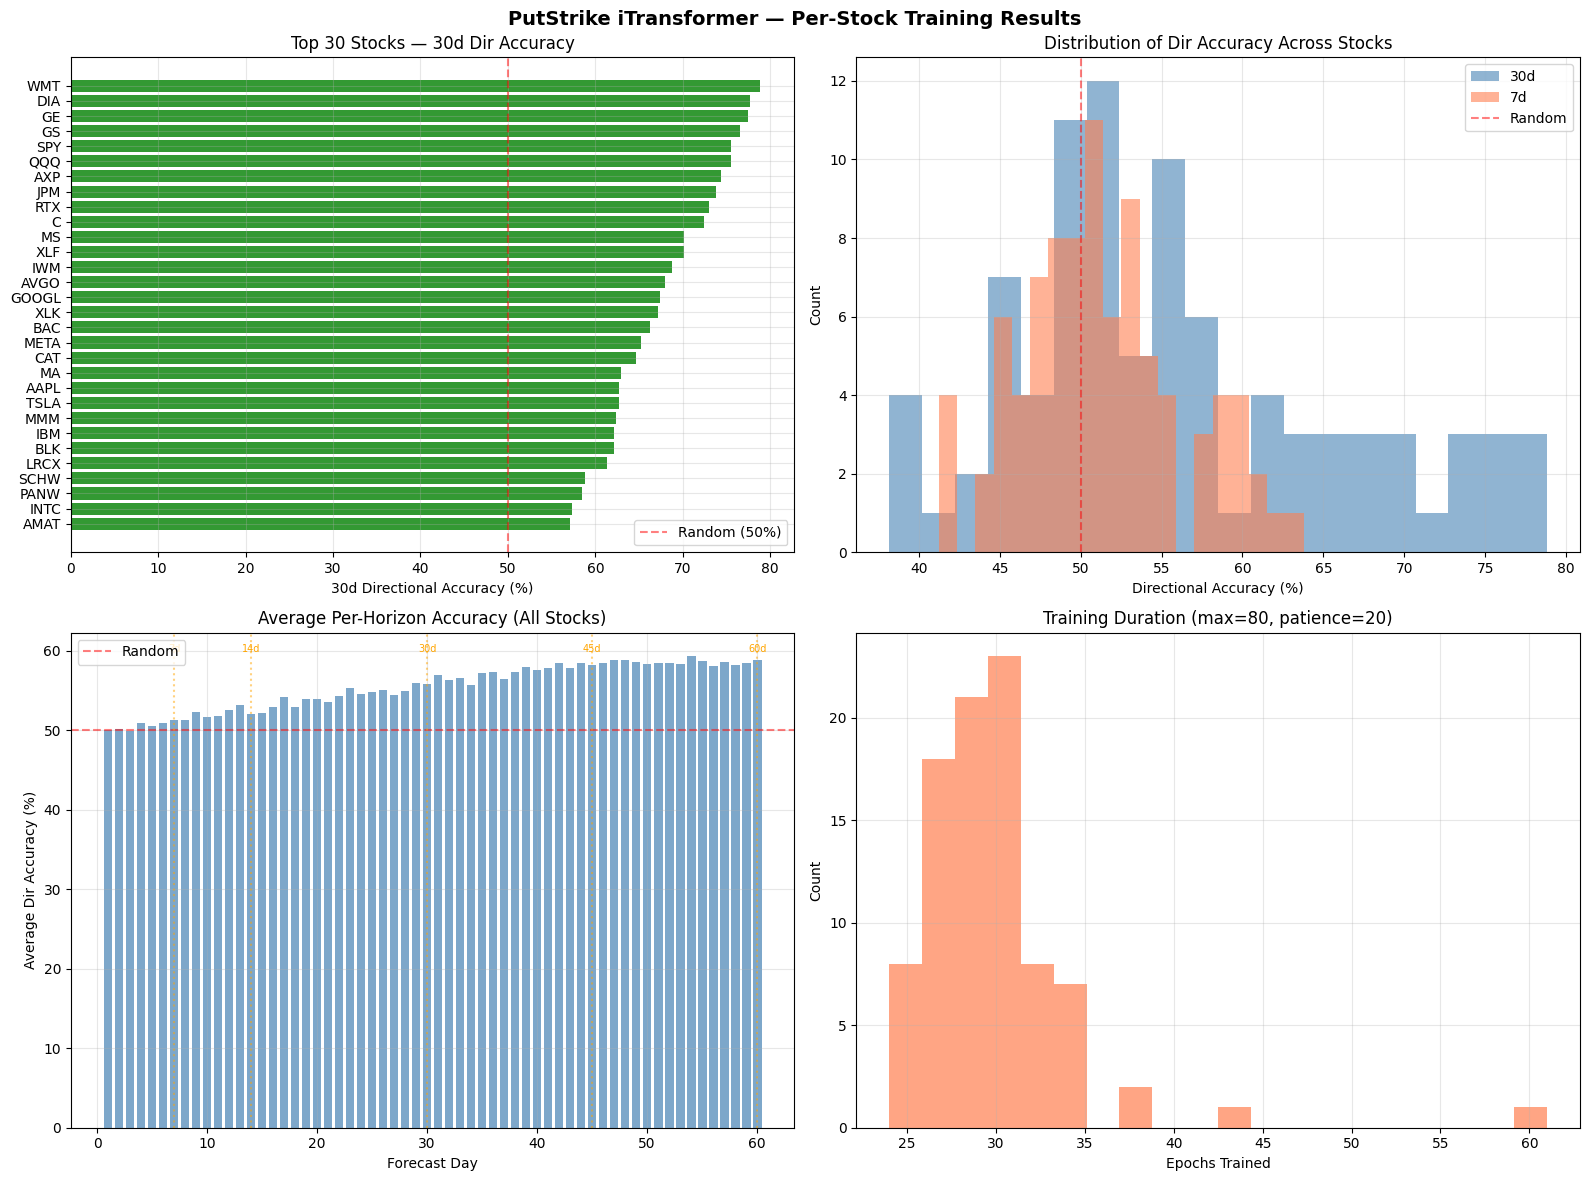


[SUMMARY]
  Models trained:     89
  Avg 7d Dir Acc:     51.3% (std=4.9%)
  Avg 30d Dir Acc:    55.8% (std=10.1%)
  Avg epochs:         30
  Best stock (30d):   WMT (78.8%)
  Worst stock (30d):  XBI (38.2%)


In [16]:
# Cell 8: Training Visualization

import matplotlib.pyplot as plt

# Summary bar chart of 30d directional accuracy per stock
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("PutStrike iTransformer — Per-Stock Training Results", fontsize=14, fontweight="bold")

# Top-left: 30d directional accuracy per stock
ax1 = axes[0, 0]
symbols_sorted = sorted(per_stock_metrics.keys(), key=lambda s: per_stock_metrics[s]["dir_acc_30d"], reverse=True)
accs = [per_stock_metrics[s]["dir_acc_30d"] for s in symbols_sorted]
colors = ["green" if a > 55 else "steelblue" if a > 50 else "orange" for a in accs]
ax1.barh(symbols_sorted[:30], accs[:30], color=colors[:30], alpha=0.8)
ax1.axvline(x=50, color="red", linestyle="--", alpha=0.5, label="Random (50%)")
ax1.set_xlabel("30d Directional Accuracy (%)")
ax1.set_title(f"Top 30 Stocks — 30d Dir Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.invert_yaxis()

# Top-right: Distribution of directional accuracies
ax2 = axes[0, 1]
all_dir30 = [m["dir_acc_30d"] for m in per_stock_metrics.values()]
all_dir7 = [m["dir_acc_7d"] for m in per_stock_metrics.values()]
ax2.hist(all_dir30, bins=20, alpha=0.6, label="30d", color="steelblue")
ax2.hist(all_dir7, bins=20, alpha=0.6, label="7d", color="coral")
ax2.axvline(x=50, color="red", linestyle="--", alpha=0.5, label="Random")
ax2.set_xlabel("Directional Accuracy (%)")
ax2.set_ylabel("Count")
ax2.set_title("Distribution of Dir Accuracy Across Stocks")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Bottom-left: Average per-horizon accuracy across all stocks
ax3 = axes[1, 0]
avg_horizon = np.mean([m["horizon_dir_acc"] for m in per_stock_metrics.values()], axis=0)
days = list(range(1, len(avg_horizon) + 1))
ax3.bar(days, avg_horizon, alpha=0.7, color="steelblue")
ax3.axhline(y=50, color="red", linestyle="--", alpha=0.5, label="Random")
for d, label in [(7, "7d"), (14, "14d"), (30, "30d"), (45, "45d"), (60, "60d")]:
    if d <= len(days):
        ax3.axvline(x=d, color="orange", linestyle=":", alpha=0.5)
        ax3.text(d, max(avg_horizon) + 0.5, label, ha="center", fontsize=7, color="orange")
ax3.set_xlabel("Forecast Day")
ax3.set_ylabel("Average Dir Accuracy (%)")
ax3.set_title("Average Per-Horizon Accuracy (All Stocks)")
ax3.legend()
ax3.grid(True, alpha=0.3)

# Bottom-right: Training epochs distribution
ax4 = axes[1, 1]
epochs_list = [m["epochs_trained"] for m in per_stock_metrics.values()]
ax4.hist(epochs_list, bins=20, alpha=0.7, color="coral")
ax4.set_xlabel("Epochs Trained")
ax4.set_ylabel("Count")
ax4.set_title(f"Training Duration (max={EPOCHS}, patience={PATIENCE})")
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_results.png", dpi=150, bbox_inches="tight")
plt.show()

# Print summary stats
print(f"\n[SUMMARY]")
print(f"  Models trained:     {len(per_stock_metrics)}")
print(f"  Avg 7d Dir Acc:     {np.mean(all_dir7):.1f}% (std={np.std(all_dir7):.1f}%)")
print(f"  Avg 30d Dir Acc:    {np.mean(all_dir30):.1f}% (std={np.std(all_dir30):.1f}%)")
print(f"  Avg epochs:         {np.mean(epochs_list):.0f}")
print(f"  Best stock (30d):   {symbols_sorted[0]} ({per_stock_metrics[symbols_sorted[0]]['dir_acc_30d']:.1f}%)")
print(f"  Worst stock (30d):  {symbols_sorted[-1]} ({per_stock_metrics[symbols_sorted[-1]]['dir_acc_30d']:.1f}%)")

In [17]:
# Cell 9: Save Config & Push to HuggingFace Hub

from huggingface_hub import HfApi, create_repo
import glob as glob_module

print("[3/5] Saving configs and pushing to HuggingFace Hub...")

# Save per-stock config
per_stock_config = {
    "model_name": "putstrike-itransformer-per-stock",
    "version": "4.0",
    "feature_names": feature_names,
    "num_features": len(feature_names),
    "lookback": LOOKBACK_WINDOW,
    "forecast_horizon": FORECAST_HORIZON,
    "architecture": {
        "type": "iTransformer",
        "d_model": D_MODEL,
        "n_layers": N_LAYERS,
        "n_heads": N_HEADS,
        "d_ff": D_FF,
        "dropout": DROPOUT,
        "use_revin": True,
    },
    "training": {
        "symbols": list(per_stock_metrics.keys()),
        "num_stocks": len(per_stock_metrics),
        "epochs": EPOCHS,
        "patience": PATIENCE,
        "batch_size": BATCH_SIZE,
        "lr": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "min_samples": MIN_SAMPLES,
        "data_years": DATA_YEARS,
        "loss_function": "HuberLoss(delta=0.02)",
        "optimizer": "AdamW",
        "lr_schedule": "warmup + cosine decay",
        "validation": "walk-forward (70/15/15)",
    },
    "per_stock_metrics": per_stock_metrics,
    "failed_stocks": per_stock_failed,
    "normalization_stats": norm_stats,
}

with open("per_stock/per_stock_config.json", "w") as f:
    json.dump(per_stock_config, f, indent=2)

# Also save as model_config.json (website expects this)
model_config = {
    "model_name": "putstrike-itransformer-per-stock",
    "version": "4.0",
    "feature_names": feature_names,
    "num_features": len(feature_names),
    "lookback": LOOKBACK_WINDOW,
    "forecast_horizon": FORECAST_HORIZON,
    "architecture": {
        "type": "iTransformer (per-stock)",
        "d_model": D_MODEL,
        "n_layers": N_LAYERS,
        "n_heads": N_HEADS,
        "d_ff": D_FF,
        "dropout": DROPOUT,
        "use_revin": True,
        "parameters": None,  # set below
    },
    "training": {
        "symbols": list(per_stock_metrics.keys()),
        "num_stocks": len(per_stock_metrics),
        "total_samples": sum(m["num_samples"] for m in per_stock_metrics.values()),
        "epochs_trained": int(np.mean([m["epochs_trained"] for m in per_stock_metrics.values()])),
        "best_val_loss": float(np.mean([m["best_val_loss"] for m in per_stock_metrics.values()])),
    },
    "test_metrics": {
        "mse": float(np.mean([m["mse"] for m in per_stock_metrics.values()])),
        "mae": float(np.mean([m["mae"] for m in per_stock_metrics.values()])),
        "dir_acc_7d": float(np.mean([m["dir_acc_7d"] for m in per_stock_metrics.values()])),
        "dir_acc_14d": float(np.mean([m["dir_acc_14d"] for m in per_stock_metrics.values()])),
        "dir_acc_30d": float(np.mean([m["dir_acc_30d"] for m in per_stock_metrics.values()])),
        "dir_acc_60d": float(np.mean([m["dir_acc_60d"] for m in per_stock_metrics.values()])),
        "horizon_dir_acc": np.mean([m["horizon_dir_acc"] for m in per_stock_metrics.values()], axis=0).tolist(),
    },
    "normalization_stats": norm_stats,
}

# Calculate param count from one model
dummy_model = iTransformer(
    num_variates=len(feature_names), lookback=LOOKBACK_WINDOW,
    forecast_horizon=FORECAST_HORIZON, d_model=D_MODEL,
    n_layers=N_LAYERS, n_heads=N_HEADS, d_ff=D_FF, dropout=DROPOUT,
)
model_config["architecture"]["parameters"] = sum(p.numel() for p in dummy_model.parameters())
del dummy_model

with open("model_config.json", "w") as f:
    json.dump(model_config, f, indent=2)

print(f"  Saved: per_stock/per_stock_config.json")
print(f"  Saved: model_config.json")

# ── Push to HuggingFace Hub ──
print(f"\n[4/5] Pushing to HuggingFace Hub...")

api = HfApi(token=HF_TOKEN)

# Create repo if it doesn't exist
try:
    create_repo(HF_REPO_ID, token=HF_TOKEN, repo_type="model", exist_ok=True)
    print(f"  Repo: https://huggingface.co/{HF_REPO_ID}")
except Exception as e:
    print(f"  Repo creation: {e}")

# Upload model_config.json (website needs this)
api.upload_file(
    path_or_fileobj="model_config.json",
    path_in_repo="model_config.json",
    repo_id=HF_REPO_ID,
    token=HF_TOKEN,
)
print(f"  Uploaded: model_config.json")

# Upload per-stock models
per_stock_onnx_files = sorted(glob_module.glob("per_stock/*.onnx"))
print(f"\n  Uploading {len(per_stock_onnx_files)} per-stock models...")
for onnx_file in per_stock_onnx_files:
    sym_name = os.path.basename(onnx_file).replace(".onnx", "")
    file_size = os.path.getsize(onnx_file) / (1024 * 1024)
    api.upload_file(
        path_or_fileobj=onnx_file,
        path_in_repo=f"per_stock/{sym_name}.onnx",
        repo_id=HF_REPO_ID,
        token=HF_TOKEN,
    )
    print(f"    {sym_name}.onnx ({file_size:.1f} MB)")

# Upload per-stock config
api.upload_file(
    path_or_fileobj="per_stock/per_stock_config.json",
    path_in_repo="per_stock/per_stock_config.json",
    repo_id=HF_REPO_ID,
    token=HF_TOKEN,
)
print(f"  Uploaded: per_stock/per_stock_config.json")

# Upload training visualization
if os.path.exists("training_results.png"):
    api.upload_file(
        path_or_fileobj="training_results.png",
        path_in_repo="training_results.png",
        repo_id=HF_REPO_ID,
        token=HF_TOKEN,
    )
    print(f"  Uploaded: training_results.png")

# Upload README
avg_dir30 = np.mean([m["dir_acc_30d"] for m in per_stock_metrics.values()])
avg_dir7 = np.mean([m["dir_acc_7d"] for m in per_stock_metrics.values()])
param_count = model_config["architecture"]["parameters"]

readme_content = f"""---
tags:
  - time-series
  - finance
  - itransformer
  - onnx
  - stock-prediction
license: mit
---

# PutStrike iTransformer — Per-Stock Forecasting Models

**iTransformer** (ICLR 2024) — individual models trained per stock for {FORECAST_HORIZON}-day price forecasting.

## Per-Stock Models

**{len(per_stock_metrics)} individual per-stock models**, each under `per_stock/{{SYMBOL}}.onnx`.

- **Architecture**: iTransformer with RevIN ({param_count:,} parameters each)
- **Input**: {LOOKBACK_WINDOW} days x {len(feature_names)} features (OHLCV technicals + macro)
- **Output**: {FORECAST_HORIZON}-day forward return forecast
- **Training**: Walk-forward validation (70/15/15), HuberLoss(delta=0.02)
- **Average 7-day directional accuracy**: {avg_dir7:.1f}%
- **Average 30-day directional accuracy**: {avg_dir30:.1f}%

## Usage

```python
import onnxruntime as ort
import numpy as np

# Load per-stock model
session = ort.InferenceSession("per_stock/AAPL.onnx")

# features shape: (1, {LOOKBACK_WINDOW}, {len(feature_names)})
output = session.run(None, {{"features": features}})[0]
# output shape: (1, {FORECAST_HORIZON}) — predicted returns
```

## Disclaimer

This model is for research and educational purposes only. Not financial advice.
"""

api.upload_file(
    path_or_fileobj=readme_content.encode(),
    path_in_repo="README.md",
    repo_id=HF_REPO_ID,
    token=HF_TOKEN,
)
print(f"  Uploaded: README.md")

print(f"\n  Models available at: https://huggingface.co/{HF_REPO_ID}")
print(f"  Per-stock: https://huggingface.co/{HF_REPO_ID}/resolve/main/per_stock/{{SYMBOL}}.onnx")

[3/5] Saving configs and pushing to HuggingFace Hub...
  Saved: per_stock/per_stock_config.json
  Saved: model_config.json

[4/5] Pushing to HuggingFace Hub...
  Repo: https://huggingface.co/jcl347/putstrike
  Uploaded: model_config.json

  Uploading 89 per-stock models...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  per_stock/AAPL.onnx         :  30%|###       |  544kB / 1.79MB            

    AAPL.onnx (1.7 MB)


...

    XOM.onnx (1.7 MB)
  Uploaded: per_stock/per_stock_config.json


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  training_results.png        : 100%|##########|  196kB /  196kB            

  Uploaded: training_results.png
  Uploaded: README.md

  Models available at: https://huggingface.co/jcl347/putstrike
  Per-stock: https://huggingface.co/jcl347/putstrike/resolve/main/per_stock/{SYMBOL}.onnx


In [18]:
# Cell 10: Final Summary

print("=" * 60)
print("  PutStrike iTransformer — Training Complete!")
print("=" * 60)

avg_dir30 = np.mean([m["dir_acc_30d"] for m in per_stock_metrics.values()])
avg_dir7 = np.mean([m["dir_acc_7d"] for m in per_stock_metrics.values()])
total_size = sum(m["onnx_size_mb"] for m in per_stock_metrics.values())

print(f"""
  Architecture: Per-Stock iTransformer v4.0
  Stocks trained: {len(per_stock_metrics)}
  Features: {len(feature_names)}
  Total ONNX size: {total_size:.1f} MB ({len(per_stock_metrics)} models)

  Average Directional Accuracy:
    7-day:  {avg_dir7:.1f}%
    14-day: {np.mean([m['dir_acc_14d'] for m in per_stock_metrics.values()]):.1f}%
    30-day: {avg_dir30:.1f}%
    60-day: {np.mean([m['dir_acc_60d'] for m in per_stock_metrics.values()]):.1f}%

  Next Steps:
  1. Set HF_REPO_ID in your website's .env:
     NEXT_PUBLIC_HF_REPO_ID={HF_REPO_ID}
  2. The website will auto-download the per-stock ONNX model for each ticker
  3. Predictions run via onnxruntime-web (WASM, no GPU needed)
  4. Re-run this notebook periodically to retrain with fresh data
""")

print("[5/5] Done!")

  PutStrike iTransformer — Training Complete!

  Architecture: Per-Stock iTransformer v4.0
  Stocks trained: 89
  Features: 83
  Total ONNX size: 152.2 MB (89 models)

  Average Directional Accuracy:
    7-day:  51.3%
    14-day: 52.1%
    30-day: 55.8%
    60-day: 58.8%

  Next Steps:
  1. Set HF_REPO_ID in your website's .env:
     NEXT_PUBLIC_HF_REPO_ID=jcl347/putstrike
  2. The website will auto-download the per-stock ONNX model for each ticker
  3. Predictions run via onnxruntime-web (WASM, no GPU needed)
  4. Re-run this notebook periodically to retrain with fresh data

[5/5] Done!
